In [18]:
from pathlib import Path

BASE = Path("/kaggle/input/datasets/tiinh123")

ds1_img  = BASE / "table-segmentation-1/table_segmentation/data/images"
ds1_mask = BASE / "table-segmentation-1/table_segmentation/data/masks"
ds2_mask = BASE / "table-segmentation-2/table_segmentation/data/masks"
ds3_mask = BASE / "table-segmentation-3/table_segmentation/data/masks"

# Gom tất cả IDs có mask
all_mask_ids = set()
for mask_dir in [ds1_mask, ds2_mask, ds3_mask]:
    for f in mask_dir.glob("*_row.png"):
        all_mask_ids.add(f.stem.replace("_row", ""))

# IDs có image
all_img_ids = set(f.stem for f in ds1_img.glob("*.png"))

print(f"Total mask IDs: {len(all_mask_ids):,}")
print(f"Total image IDs: {len(all_img_ids):,}")
print(f"IDs có cả image lẫn mask: {len(all_mask_ids & all_img_ids):,}")
print(f"IDs có mask nhưng không có image: {len(all_mask_ids - all_img_ids):,}")
print(f"IDs có image nhưng không có mask: {len(all_img_ids - all_mask_ids):,}")

Total mask IDs: 30,000
Total image IDs: 30,000
IDs có cả image lẫn mask: 30,000
IDs có mask nhưng không có image: 0
IDs có image nhưng không có mask: 0


In [3]:
from pathlib import Path

BASE = Path("/kaggle/input/datasets/tiinh123")

IMG_DIR  = BASE / "table-segmentation-1/table_segmentation/data/images"

# Gom masks từ 3 dataset vào 1 dict
MASK_DIRS = [
    BASE / "table-segmentation-1/table_segmentation/data/masks",
    BASE / "table-segmentation-2/table_segmentation/data/masks",
    BASE / "table-segmentation-3/table_segmentation/data/masks",
]

# Build lookup: sid → mask_dir
mask_dir_lookup = {}
for mask_dir in MASK_DIRS:
    for f in mask_dir.glob("*_row.png"):
        sid = f.stem.replace("_row", "")
        mask_dir_lookup[sid] = mask_dir

print(f"Images:    {len(list(IMG_DIR.glob('*.png'))):,}")
print(f"Mask lookup: {len(mask_dir_lookup):,}")

# Lấy all_ids
all_ids = sorted(mask_dir_lookup.keys())
print(f"Total IDs: {len(all_ids):,}")

Images:    30,000
Mask lookup: 30,000
Total IDs: 30,000


In [7]:
# ── Imports ───────────────────────────────────────────────
import torch
import random
import numpy as np
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# ── Đường dẫn ─────────────────────────────────────────────
BASE = Path("/kaggle/input/datasets/tiinh123")

IMG_DIR  = BASE / "table-segmentation-1/table_segmentation/data/images"
IMG_SIZE = 384

MASK_DIRS = [
    BASE / "table-segmentation-1/table_segmentation/data/masks",
    BASE / "table-segmentation-2/table_segmentation/data/masks",
    BASE / "table-segmentation-3/table_segmentation/data/masks",
]

# Build lookup: sid → mask_dir
mask_dir_lookup = {}
for mask_dir in MASK_DIRS:
    for f in mask_dir.glob("*_row.png"):
        sid = f.stem.replace("_row", "")
        mask_dir_lookup[sid] = mask_dir

all_ids = sorted(mask_dir_lookup.keys())

print(f"Images:      {len(list(IMG_DIR.glob('*.png'))):,}")
print(f"Mask lookup: {len(mask_dir_lookup):,}")
print(f"Total IDs:   {len(all_ids):,}")

Images:      30,000
Mask lookup: 30,000
Total IDs:   30,000


In [8]:
# ── Imports ───────────────────────────────────────────────
import torch
import random
import numpy as np
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# ── Config ────────────────────────────────────────────────
BATCH_SIZE = 8
IMG_SIZE   = 384
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Đường dẫn ─────────────────────────────────────────────
BASE = Path("/kaggle/input/datasets/tiinh123")

IMG_DIR = BASE / "table-segmentation-1/table_segmentation/data/images"

MASK_DIRS = [
    BASE / "table-segmentation-1/table_segmentation/data/masks",
    BASE / "table-segmentation-2/table_segmentation/data/masks",
    BASE / "table-segmentation-3/table_segmentation/data/masks",
]

# Build lookup: sid → mask_dir
mask_dir_lookup = {}
for mask_dir in MASK_DIRS:
    for f in mask_dir.glob("*_row.png"):
        sid = f.stem.replace("_row", "")
        mask_dir_lookup[sid] = mask_dir

all_ids = sorted(mask_dir_lookup.keys())

print(f"Images:      {len(list(IMG_DIR.glob('*.png'))):,}")
print(f"Mask lookup: {len(mask_dir_lookup):,}")
print(f"Total IDs:   {len(all_ids):,}")
print(f"Device:      {device}")
# ── CELL 2: Dataset ───────────────────────────────────────
class TableDataset(Dataset):
    MASK_TYPES = ["row", "col", "col_header", "row_header", "span"]

    def __init__(self, sample_ids, augment=False):
        self.sample_ids = sample_ids
        self.augment    = augment

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sid = self.sample_ids[idx]
    
        img  = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
        mask_dir = mask_dir_lookup[sid]  # tự động chọn đúng thư mục
    
        masks = {}
        for mtype in self.MASK_TYPES:
            p = mask_dir / f"{sid}_{mtype}.png"
            masks[mtype] = Image.open(p).convert("L") if p.exists() \
                else Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE), np.uint8))
    
        if self.augment:
            img, masks = self._augment(img, masks)

        img = TF.resize(img, (IMG_SIZE, IMG_SIZE), 
                    interpolation=TF.InterpolationMode.BILINEAR)
        masks = {k: TF.resize(v, (IMG_SIZE, IMG_SIZE),
                    interpolation=TF.InterpolationMode.NEAREST)
             for k, v in masks.items()}
    
        img_t  = TF.to_tensor(img)
        mask_t = torch.cat([
            (TF.to_tensor(masks[m]) > 0.5).float()
            for m in self.MASK_TYPES
        ], dim=0)
        return {"image": img_t, "masks": mask_t, "sample_id": sid}

    def _augment(self, img, masks):
        all_imgs = [img] + list(masks.values())

        # GIỮ NGUYÊN: rotate
        if random.random() > 0.5:
            angle = random.uniform(-3, 3)
            all_imgs = [TF.rotate(i, angle) for i in all_imgs]

        # THÊM MỚI: horizontal flip
        if random.random() > 0.5:
            all_imgs = [TF.hflip(i) for i in all_imgs]

        # THÊM MỚI: random crop rồi resize lại 256x256
        if random.random() > 0.5:
            w, h = img.size
            crop_size = random.randint(200, 240)
            ci = random.randint(0, h - crop_size)
            cj = random.randint(0, w - crop_size)
            all_imgs = [
                TF.resized_crop(
                    x, ci, cj, crop_size, crop_size, (h, w),
                    interpolation = (TF.InterpolationMode.BILINEAR
                                       if aug_idx == 0
                                       else TF.InterpolationMode.NEAREST)
                                    )
                for aug_idx, x in enumerate(all_imgs)
            ]

        # GIỮ NGUYÊN: brightness/contrast
        if random.random() > 0.5:
            all_imgs[0] = TF.adjust_brightness(all_imgs[0], random.uniform(0.8, 1.2))
            all_imgs[0] = TF.adjust_contrast(all_imgs[0], random.uniform(0.8, 1.2))

        img = all_imgs[0]
        for k, key in enumerate(masks.keys()):
            masks[key] = all_imgs[k+1]
        return img, masks

# Split train/val
random.seed(42)
random.shuffle(all_ids)
n_val     = int(len(all_ids) * 0.1)
train_ids = all_ids[:-n_val]
val_ids   = all_ids[-n_val:]

train_ds = TableDataset(train_ids, augment=True)
val_ds   = TableDataset(val_ids,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# Verify 1 batch
batch = next(iter(train_loader))
print(f"Image shape: {batch['image'].shape}")
print(f"Masks shape: {batch['masks'].shape}")
print(f"Masks unique: {batch['masks'].unique().tolist()}")

Images:      30,000
Mask lookup: 30,000
Total IDs:   30,000
Device:      cuda
Train: 27,000 | Val: 3,000
Train batches: 3375 | Val batches: 375
Image shape: torch.Size([8, 3, 384, 384])
Masks shape: torch.Size([8, 5, 384, 384])
Masks unique: [0.0, 1.0]


Sample: sample_007401
Image size: (256, 256)


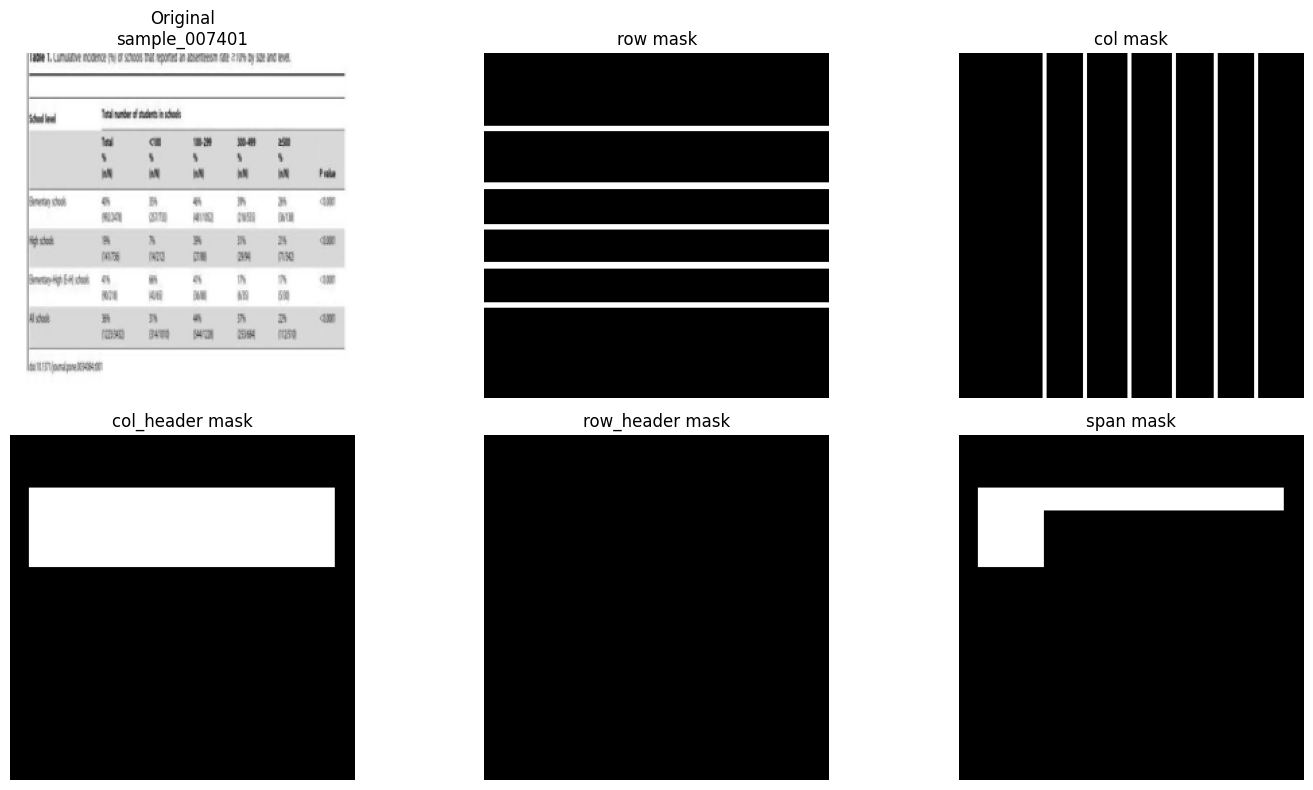


📊 Mask stats:
  row         : 8.6% white pixels
  col         : 7.0% white pixels
  col_header  : 20.4% white pixels
  row_header  : 0.0% white pixels
  span        : 9.0% white pixels


In [9]:
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random

# Lấy 1 sample ngẫu nhiên
sample_ids = [f.stem for f in sorted(IMG_DIR.glob("*.png"))]
sid = random.choice(sample_ids)
print(f"Sample: {sid}")

# Load ảnh
img = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
print(f"Image size: {img.size}")

# Load và visualize 5 masks
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
mask_names = ["row", "col", "col_header", "row_header", "span"]

axes[0, 0].imshow(img)
axes[0, 0].set_title(f"Original\n{sid}")
axes[0, 0].axis("off")

for i, mtype in enumerate(mask_names):
    ax = axes[(i+1)//3, (i+1)%3]
    p  = mask_dir_lookup[sid] / f"{sid}_{mtype}.png"  # dùng lookup
    if p.exists():
        mask = Image.open(p).convert("L")
        ax.imshow(mask, cmap="gray")
        ax.set_title(f"{mtype} mask")
    else:
        ax.set_title(f"{mtype} — NOT FOUND")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Thống kê masks
print("\n📊 Mask stats:")
for mtype in mask_names:
    p = mask_dir_lookup[sid] / f"{sid}_{mtype}.png"  # ← sửa MASK_DIR → mask_dir_lookup[sid]
    if p.exists():
        mask_arr = np.array(Image.open(p).convert("L"))
        white_pct = (mask_arr > 128).sum() / mask_arr.size * 100
        print(f"  {mtype:<12}: {white_pct:.1f}% white pixels")
    else:
        print(f"  {mtype:<12}: NOT FOUND")

In [8]:
# Kiểm tra số file thực tế trong từng thư mục
for mask_dir in MASK_DIRS:
    row_files = list(mask_dir.glob("*_row.png"))
    print(f"{mask_dir.parent.parent.name}: {len(row_files):,} row masks")

print(f"\nTotal trong lookup: {len(mask_dir_lookup):,}")
print(f"Total images:       {len(list(IMG_DIR.glob('*.png'))):,}")

table_segmentation: 7,101 row masks
table_segmentation: 13,107 row masks
table_segmentation: 9,792 row masks

Total trong lookup: 30,000
Total images:       30,000


In [9]:
# Chạy lại để đảm bảo all_ids đủ 30k
all_ids = sorted(mask_dir_lookup.keys())
print(f"all_ids: {len(all_ids):,}")  # phải ra 30,000

all_ids: 30,000


In [22]:
from scipy.ndimage import binary_dilation
from PIL import Image
import numpy as np
from pathlib import Path
from tqdm import tqdm
import shutil

# Xóa thư mục cũ để tránh file thừa từ lần trước
NEW_MASK_DIR = Path("/kaggle/working/masks_dilated")
if NEW_MASK_DIR.exists():
    shutil.rmtree(NEW_MASK_DIR)
NEW_MASK_DIR.mkdir(exist_ok=True)

DILATE_ITER = 1

# Rebuild all_ids ngay tại đây để chắc chắn
all_ids = sorted(mask_dir_lookup.keys())
print(f"✅ all_ids: {len(all_ids):,}")  # phải ra 30,000 trước khi chạy

for sid in tqdm(all_ids):
    src_dir = mask_dir_lookup[sid]

    for mtype in ["row", "col_header", "row_header", "span"]:
        p = src_dir / f"{sid}_{mtype}.png"
        if p.exists():
            shutil.copy2(p, NEW_MASK_DIR / f"{sid}_{mtype}.png")

    p_col = src_dir / f"{sid}_col.png"
    if p_col.exists():
        mask = np.array(Image.open(p_col).convert("L"))
        dilated = binary_dilation(mask > 128, iterations=DILATE_ITER)
        Image.fromarray(dilated.astype(np.uint8) * 255).save(
            NEW_MASK_DIR / f"{sid}_col.png"
        )

print(f"✅ Done! Total files: {len(list(NEW_MASK_DIR.glob('*.png'))):,}")

✅ all_ids: 30,000


100%|██████████| 30000/30000 [26:15<00:00, 19.04it/s] 


✅ Done! Total files: 149,826


In [28]:
import json, shutil, subprocess
from pathlib import Path

MASKS_BACKUP = Path("/kaggle/working/masks_backup")
if MASKS_BACKUP.exists():
    shutil.rmtree(MASKS_BACKUP)
MASKS_BACKUP.mkdir()

print("Copying masks...")
shutil.copytree(NEW_MASK_DIR, MASKS_BACKUP / "masks_dilated")

with open(MASKS_BACKUP / "dataset-metadata.json", "w") as f:
    json.dump({
        "title": "table-seg-masks-dilated",
        "id": "tiinh123/table-seg-masks-dilated",
        "licenses": [{"name": "CC0-1.0"}]
    }, f)

result = subprocess.run(
    f'kaggle datasets create -p {MASKS_BACKUP} --dir-mode tar',
    shell=True,
    capture_output=True,
    text=True
)


print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)

Copying masks...
STDOUT: Starting upload for file masks_dilated.tar
Upload successful: masks_dilated.tar (308MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/tiinh123/table-seg-masks-dilated

STDERR: 
  0%|          | 0.00/308M [00:00<?, ?B/s]
  3%|▎         | 8.36M/308M [00:00<00:03, 80.3MB/s]
  9%|▉         | 28.7M/308M [00:00<00:02, 134MB/s] 
 13%|█▎        | 41.2M/308M [00:00<00:02, 124MB/s]
 17%|█▋        | 52.8M/308M [00:00<00:02, 105MB/s]
 23%|██▎       | 70.8M/308M [00:00<00:01, 128MB/s]
 27%|██▋       | 83.5M/308M [00:00<00:02, 117MB/s]
 32%|███▏      | 97.8M/308M [00:00<00:01, 126MB/s]
 36%|███▌      | 110M/308M [00:01<00:01, 104MB/s] 
 40%|███▉      | 123M/308M [00:01<00:01, 108MB/s]
 44%|████▎     | 134M/308M [00:01<00:01, 101MB/s]
 48%|████▊     | 149M/308M [00:01<00:01, 113MB/s]
 52%|█████▏    | 161M/308M [00:01<00:01, 116MB/s]
 56%|█████▌    | 172M/308M [00:01<00:01, 115MB/s]
 61%|██████▏   | 189M/308M [00:01<00:00, 132M

In [29]:
for sid in all_ids:
    mask_dir_lookup[sid] = NEW_MASK_DIR
print(f"✅ mask_dir_lookup → {NEW_MASK_DIR}")
print(f"   Total masks: {len(list(NEW_MASK_DIR.glob('*.png'))):,}")

✅ mask_dir_lookup → /kaggle/working/masks_dilated
   Total masks: 149,826


In [15]:
import random

sample_check = random.sample(all_ids, 10)
for sid in sample_check:
    p = NEW_MASK_DIR / f"{sid}_col.png"
    if p.exists():
        mask = np.array(Image.open(p).convert("L"))
        pct = (mask > 128).mean() * 100
        print(f"{sid}: {pct:.1f}%")
    else:
        print(f"{sid}: col mask NOT FOUND")

sample_007991: 5.9%
sample_018893: 9.8%
sample_008922: 7.8%
sample_013802: 5.5%
sample_028717: 2.3%
sample_025974: 15.2%
sample_015922: 7.8%
sample_026342: 7.0%
sample_012697: 13.7%
sample_013375: 7.4%


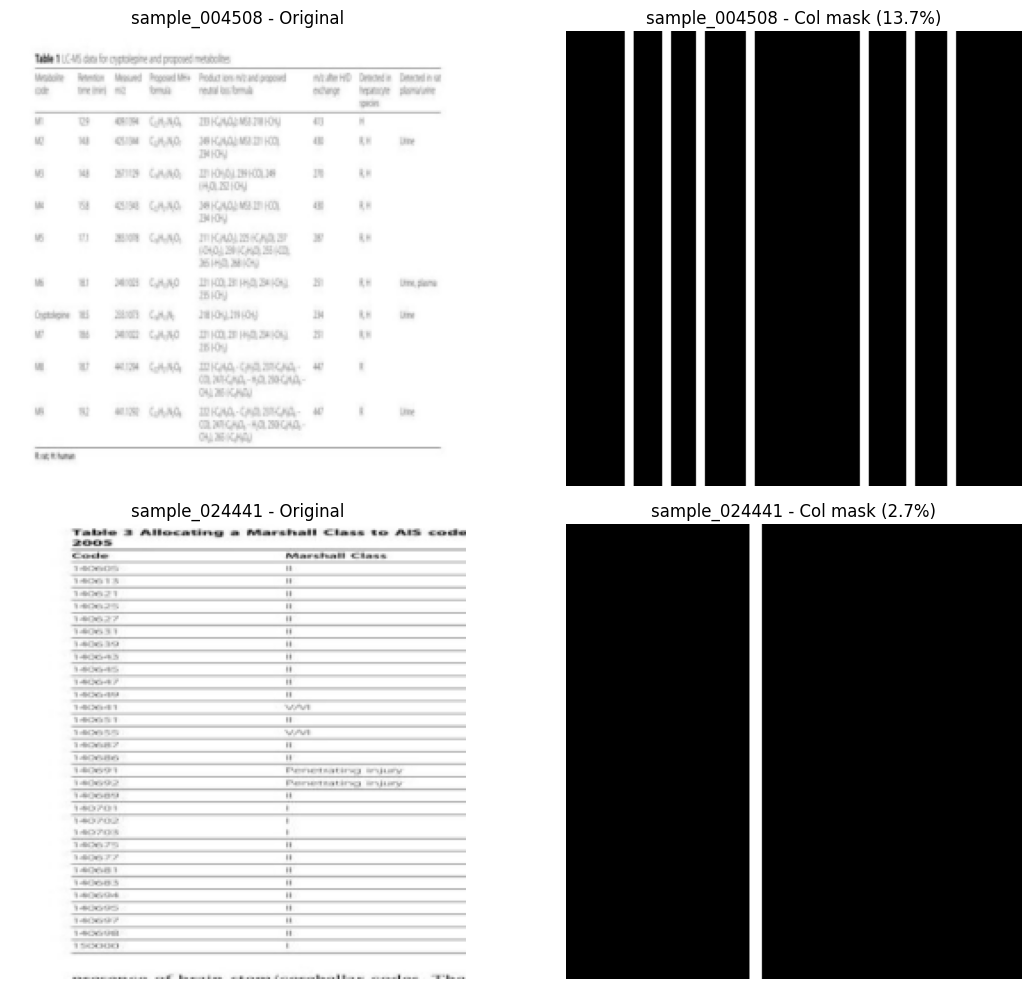

In [16]:
import matplotlib.pyplot as plt

suspicious = ["sample_004508", "sample_024441"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, sid in enumerate(suspicious):
    # Ảnh gốc
    img = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{sid} - Original")
    axes[i, 0].axis("off")

    # Col mask sau dilate
    mask = Image.open(NEW_MASK_DIR / f"{sid}_col.png").convert("L")
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"{sid} - Col mask ({(np.array(mask)>128).mean()*100:.1f}%)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ── CELL 3: EfficientNet-B4 + UNet Decoder ───────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class EfficientUNet(nn.Module):
    def __init__(self, out_ch=5, pretrained=True):
        super().__init__()

        # ── Encoder: EfficientNet-B4 ──────────────────
        self.encoder = timm.create_model(
            "efficientnet_b4",
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3, 4),
        )
        # EfficientNet-B4 channel sizes: 24, 32, 56, 160, 448
        enc_chs = self.encoder.feature_info.channels()  # [24,32,56,160,448]

        # ── Bottleneck ────────────────────────────────
        self.bottleneck = nn.Sequential(
            nn.Conv2d(enc_chs[4], 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        # ── Decoder blocks ────────────────────────────
        self.dec4 = self._dec_block(256 + enc_chs[3], 128)
        self.dec3 = self._dec_block(128 + enc_chs[2], 64)
        self.dec2 = self._dec_block(64  + enc_chs[1], 32)
        self.dec1 = self._dec_block(32  + enc_chs[0], 16)
        self.dec0 = self._dec_block(16, 16)  # upsample về 256x256

        # ── Output ────────────────────────────────────
        self.out_conv = nn.Conv2d(16, out_ch, 1)

    def _dec_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        feats = self.encoder(x)  # [s0,s1,s2,s3,s4]
        s0, s1, s2, s3, s4 = feats

        # Bottleneck
        b = self.bottleneck(s4)

        # Decoder + skip connections
        x = F.interpolate(b,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec4(torch.cat([x, s3], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec3(torch.cat([x, s2], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec2(torch.cat([x, s1], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec1(torch.cat([x, s0], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec0(x)

        return self.out_conv(x)


# ── Verify ────────────────────────────────────────────────
model = EfficientUNet(out_ch=5, pretrained=True).to(device)
dummy = torch.randn(2, 3, 384, 384).to(device)
with torch.no_grad():
    out = model(dummy)

total = sum(p.numel() for p in model.parameters())
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}")
print(f"Params: {total/1e6:.1f}M")
print(f"Output size match: {out.shape[-2:] == torch.Size([384, 384])}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Input:  torch.Size([2, 3, 384, 384])
Output: torch.Size([2, 5, 384, 384])
Params: 19.2M
Output size match: True


In [20]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("KAGGLE_KEY")
secret_value_1 = user_secrets.get_secret("KAGGLE_USERNAME")


In [21]:
# ── Setup Kaggle API ──────────────────────────────────────
import os, json
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
os.makedirs("/root/.kaggle", exist_ok=True)

creds = {
    "username": secrets.get_secret("KAGGLE_USERNAME"),
    "key":      secrets.get_secret("KAGGLE_KEY")
}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(creds, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Test
import subprocess
result = subprocess.run(
    ["kaggle", "datasets", "list", "--mine"],
    capture_output=True, text=True)
print(result.stdout)
print("✅ Kaggle API ready!")

ref                               title                          size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------  -----------------------  ----------  --------------------------  -------------  ---------  ---------------  
tiinh123/table-segmentation-data  table-segmentation-data   767733887  2026-03-23 03:08:18.943000              0          0  0.25             
tiinh123/table-seg-checkpoints    table-seg-checkpoints     638487672  2026-03-26 15:05:29.190000              0          0  0.25             
tiinh123/table-segmentation-1     table_segmentation_1     1248986910  2026-03-26 03:28:47.747000              0          0  0.0              
tiinh123/table-segmentation-2     table_segmentation_2       22919737  2026-03-26 03:33:22.723000              0          0  0.0              
tiinh123/table-segmentation-3     table_segmentation_3       17010225  2026-03-26 03:35:36.997000              0          0  0.0              

Train batches: 1688 | Val batches: 188


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


🆕 Starting fresh...
Training 1 → 60 | batch=16 | lr=0.0002 | device=cuda

Epoch  1/60 | Train=1.1272 Val=0.8552 mIoU=0.4513 | 1180s
  ✅ Best saved + backed up (mIoU=0.4513)
Epoch  2/60 | Train=0.7318 Val=0.6384 mIoU=0.5236 | 527s
  ✅ Best saved + backed up (mIoU=0.5236)
Epoch  3/60 | Train=0.6454 Val=0.5963 mIoU=0.5500 | 506s
  ✅ Best saved + backed up (mIoU=0.5500)
Epoch  4/60 | Train=0.6097 Val=0.6266 mIoU=0.5625 | 481s
  ✅ Best saved + backed up (mIoU=0.5625)
Epoch  5/60 | Train=0.5824 Val=0.5423 mIoU=0.5798 | 466s
  row=0.628 | col=0.455 | hdr=0.822 | rhdr=0.506 | span=0.488
  💾 Saved checkpoint_epoch5.pt
  ☁️ Backed up to Kaggle Dataset
  ✅ Best saved + backed up (mIoU=0.5798)
Epoch  6/60 | Train=0.5642 Val=0.5814 mIoU=0.5896 | 465s
  ✅ Best saved + backed up (mIoU=0.5896)
Epoch  7/60 | Train=0.5473 Val=0.5016 mIoU=0.6067 | 447s
  ✅ Best saved + backed up (mIoU=0.6067)
Epoch  8/60 | Train=0.5298 Val=0.5070 mIoU=0.6139 | 488s
  ✅ Best saved + backed up (mIoU=0.6139)
Epoch  9/60 | T

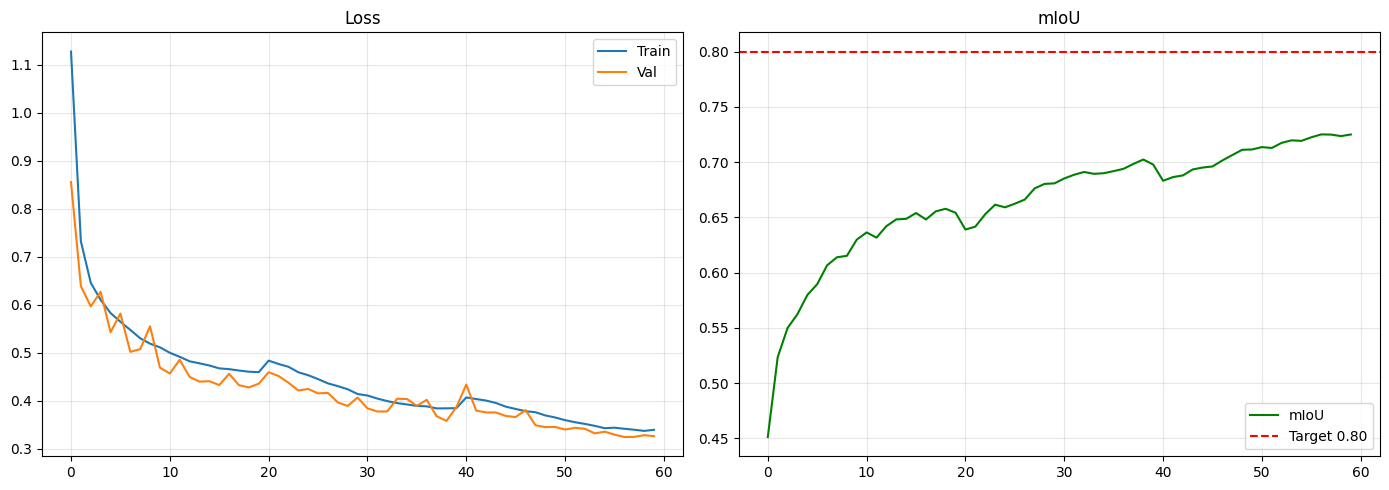


✅ Done! Best mIoU: 0.7251


In [8]:
# ── CELL 4: Training với improvements ────────────────────

import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import gc
import torch
gc.collect()
torch.cuda.empty_cache()

import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt
import time
from torch.utils.data import DataLoader
from pathlib import Path

# Config tối ưu cho T4
EPOCHS     = 40
BATCH_SIZE = 16        
LR         = 2e-4       
patience   = 15  

scaler = torch.amp.GradScaler('cuda')
# Speed up
torch.backends.cudnn.benchmark = True

# Tạo lại DataLoader với batch mới
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2, pin_memory=True)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


# ── Loss ──────────────────────────────────────────────────
class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.3):  # nghiêng về Dice
        super().__init__()
        self.bce_w = bce_weight
        self.bce   = nn.BCEWithLogitsLoss()
        self.channel_weights = torch.tensor(
            [1.0, 4.0, 1.0, 2.0, 1.5]
        )

    def dice_loss(self, pred, target, eps=1e-6):
        pred   = torch.sigmoid(pred).view(-1)
        target = target.view(-1)
        inter  = (pred * target).sum()
        return 1 - (2*inter+eps) / (pred.sum()+target.sum()+eps)

    def forward(self, pred, target):
        # Weighted loss per channel
        weights = self.channel_weights.to(pred.device)
        total   = 0
        for i in range(pred.shape[1]):
            p = pred[:, i:i+1]
            t = target[:, i:i+1]
            bce  = nn.BCEWithLogitsLoss()(p, t)
            pred_sig = torch.sigmoid(p).reshape(-1)
            t_flat   = t.reshape(-1)
            inter    = (pred_sig * t_flat).sum()
            eps      = 1e-6
            dice = 1 - (2*inter+eps)/(pred_sig.sum()+t_flat.sum()+eps)
            total += weights[i] * (self.bce_w*bce + (1-self.bce_w)*dice)
        return total / pred.shape[1]


# ── Metrics ───────────────────────────────────────────────
def compute_miou(pred_logits, target, threshold=0.5):
    pred  = (torch.sigmoid(pred_logits) > threshold).float()
    names = ["row","col","col_header","row_header","span"]
    ious  = {}
    for i, name in enumerate(names):
        p     = pred[:,i].reshape(-1)
        t     = target[:,i].reshape(-1)
        inter = (p*t).sum()
        union = (p+t-p*t).sum()
        ious[name] = (inter/union).item() if union >= 1 else float("nan")
    valid        = [v for v in ious.values() if not np.isnan(v)]
    ious["mean"] = np.mean(valid) if valid else 0.0
    return ious


# ── Train/Val functions ───────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0
    for batch in loader:
        imgs, masks = batch["image"].to(device), batch["masks"].to(device)
        optimizer.zero_grad()

        # Mixed precision
        with torch.amp.autocast('cuda'):
            loss = criterion(model(imgs), masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total += loss.item()
    return total / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    total    = 0
    all_ious = {n:[] for n in ["row","col","col_header","row_header","span"]}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch["image"].to(device), batch["masks"].to(device)
            preds = model(imgs)
            total += criterion(preds, masks).item()
            for name, val in compute_miou(preds, masks).items():
                if name != "mean" and not np.isnan(val):
                    all_ious[name].append(val)
    avg_ious         = {n: np.mean(v) if v else 0.0 for n,v in all_ious.items()}
    avg_ious["mean"] = np.mean(list(avg_ious.values()))
    return total/len(loader), avg_ious


# ── Main Training ─────────────────────────────────────────
model     = EfficientUNet(out_ch=5, pretrained=True).to(device)
criterion = DiceBCELoss(bce_weight=0.3)
import shutil, subprocess
CKPT_DIR = Path("/kaggle/working/checkpoints_effb4")
CKPT_DIR.mkdir(exist_ok=True)

optimizer = AdamW([
    {"params": model.encoder.parameters(), "lr": LR * 0.1},
    {"params": model.bottleneck.parameters()},
    {"params": model.dec4.parameters()},
    {"params": model.dec3.parameters()},
    {"params": model.dec2.parameters()},
    {"params": model.dec1.parameters()},
    {"params": model.dec0.parameters()},
    {"params": model.out_conv.parameters()},
], lr=LR, weight_decay=1e-4)

from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=1, eta_min=1e-6)
best_miou   = 0
history     = {"train_loss":[], "val_loss":[], "val_miou":[]}
start_epoch = 1

# Early stopping
patience   = 10
no_improve = 0

# Resume
last_ckpt = CKPT_DIR / "last_checkpoint.pt"
if last_ckpt.exists():
    ckpt        = torch.load(last_ckpt, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    history     = ckpt["history"]
    best_miou   = ckpt["best_miou"]
    start_epoch = ckpt["epoch"] + 1
    no_improve  = ckpt.get("no_improve", 0)
    print(f"✅ Resumed epoch {ckpt['epoch']} | mIoU={best_miou:.4f}")
else:
    print("🆕 Starting fresh...")

print(f"Training {start_epoch} → {EPOCHS} | "
      f"batch={BATCH_SIZE} | lr={LR} | device={device}\n")

for epoch in range(start_epoch, EPOCHS+1):
    t          = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_ious = validate(model, val_loader, criterion, device)
    scheduler.step()
    miou = val_ious["mean"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(miou)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train={train_loss:.4f} Val={val_loss:.4f} "
          f"mIoU={miou:.4f} | {time.time()-t:.0f}s")

    if epoch % 5 == 0:
        print(f"  row={val_ious['row']:.3f} | "
              f"col={val_ious['col']:.3f} | "
              f"hdr={val_ious['col_header']:.3f} | "
              f"rhdr={val_ious['row_header']:.3f} | "
              f"span={val_ious['span']:.3f}")

    # Checkpoint
    ckpt = {
        "epoch":      epoch,
        "model":      model.state_dict(),
        "optimizer":  optimizer.state_dict(),
        "scheduler":  scheduler.state_dict(),
        "history":    history,
        "best_miou":  best_miou,
        "no_improve": no_improve,
    }
    torch.save(ckpt, CKPT_DIR / "last_checkpoint.pt")

    if epoch % 5 == 0:
        torch.save(ckpt, CKPT_DIR / f"checkpoint_epoch{epoch}.pt")
        print(f"  💾 Saved checkpoint_epoch{epoch}.pt")
        shutil.copy2(CKPT_DIR / "last_checkpoint.pt",
                     "/kaggle/working/last_checkpoint.pt")
        subprocess.run([
            "kaggle", "datasets", "version",
            "-p", "/kaggle/working/",
            "-m", f"epoch={epoch} mIoU={miou:.4f}",
            "--dir-mode", "skip"
        ], capture_output=True)
        print(f"  ☁️ Backed up to Kaggle Dataset")
        
    # Best model + Early stopping
    if miou > best_miou:
        best_miou  = miou
        no_improve = 0
        torch.save(ckpt, CKPT_DIR / "best_model.pt")
        shutil.copy2(CKPT_DIR / "best_model.pt",
                     "/kaggle/working/best_model.pt")
        subprocess.run([
            "kaggle", "datasets", "version",
            "-p", "/kaggle/working/",
            "-m", f"BEST epoch={epoch} mIoU={best_miou:.4f}",
            "--dir-mode", "skip"
        ], capture_output=True)
        print(f"  ✅ Best saved + backed up (mIoU={best_miou:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"⛔ Early stopping at epoch {epoch} "
                  f"(no improve for {patience} epochs)")
            break

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history["val_miou"], color="green", label="mIoU")
axes[1].axhline(0.80, color="red", linestyle="--", label="Target 0.80")
axes[1].set_title("mIoU"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ Done! Best mIoU: {best_miou:.4f}")

In [31]:
import subprocess
from pathlib import Path

NEW_MASK_DIR = Path("/kaggle/working/masks_dilated")

if not NEW_MASK_DIR.exists() or len(list(NEW_MASK_DIR.glob("*.png"))) == 0:
    print("Downloading masks...")
    subprocess.run([
        "kaggle", "datasets", "download",
        "tiinh123/table-seg-masks-dilated",
        "-p", "/kaggle/working/",
        "--unzip"
    ], check=True)
    print(f"✅ {len(list(NEW_MASK_DIR.glob('*.png'))):,} masks ready")
else:
    print(f"✅ masks_dilated đã có: {len(list(NEW_MASK_DIR.glob('*.png'))):,} files")

for sid in all_ids:
    mask_dir_lookup[sid] = NEW_MASK_DIR
print(f"✅ mask_dir_lookup updated")

✅ masks_dilated đã có: 149,826 files
✅ mask_dir_lookup updated


In [11]:
# ── Before Cell 5 ──
import torch.nn as nn
import numpy as np

class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.3):
        super().__init__()
        self.bce_w = bce_weight
        self.bce   = nn.BCEWithLogitsLoss()
        self.channel_weights = torch.tensor([1.0, 4.0, 1.0, 2.0, 1.5])

    def forward(self, pred, target):
        weights = self.channel_weights.to(pred.device)
        total   = 0
        for i in range(pred.shape[1]):
            p = pred[:, i:i+1]
            t = target[:, i:i+1]
            bce      = nn.BCEWithLogitsLoss()(p, t)
            pred_sig = torch.sigmoid(p).reshape(-1)
            t_flat   = t.reshape(-1)
            inter    = (pred_sig * t_flat).sum()
            eps      = 1e-6
            dice     = 1 - (2*inter+eps)/(pred_sig.sum()+t_flat.sum()+eps)
            total   += weights[i] * (self.bce_w*bce + (1-self.bce_w)*dice)
        return total / pred.shape[1]

def compute_miou(pred_logits, target, threshold=0.5):
    pred  = (torch.sigmoid(pred_logits) > threshold).float()
    names = ["row","col","col_header","row_header","span"]
    ious  = {}
    for i, name in enumerate(names):
        p     = pred[:,i].reshape(-1)
        t     = target[:,i].reshape(-1)
        inter = (p*t).sum()
        union = (p+t-p*t).sum()
        ious[name] = (inter/union).item() if union >= 1 else float("nan")
    valid        = [v for v in ious.values() if not np.isnan(v)]
    ious["mean"] = np.mean(valid) if valid else 0.0
    return ious

scaler = torch.amp.GradScaler('cuda')

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0
    for batch in loader:
        imgs, masks = batch["image"].to(device), batch["masks"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = criterion(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
    return total / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total    = 0
    all_ious = {n:[] for n in ["row","col","col_header","row_header","span"]}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch["image"].to(device), batch["masks"].to(device)
            preds = model(imgs)
            total += criterion(preds, masks).item()
            for name, val in compute_miou(preds, masks).items():
                if name != "mean" and not np.isnan(val):
                    all_ious[name].append(val)
    avg_ious         = {n: np.mean(v) if v else 0.0 for n,v in all_ious.items()}
    avg_ious["mean"] = np.mean(list(avg_ious.values()))
    return total/len(loader), avg_ious

print("✅ Hàm đã định nghĩa xong!")

✅ Hàm đã định nghĩa xong!


In [ ]:
import os, gc, time, shutil, subprocess, json
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
gc.collect()
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True

# ── Config ────────────────────────────────────────────────
LR_FT     = 2e-6
EPOCHS_FT = 80    
patience  = 15    
CKPT_DIR   = Path("/kaggle/working/checkpoints_effb4_ft")
CKPT_DIR.mkdir(exist_ok=True)
BACKUP_DIR = Path("/kaggle/working/checkpoint_backup_ft")
BACKUP_DIR.mkdir(exist_ok=True)

scaler = torch.amp.GradScaler('cuda')

# ── DataLoader ────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ── Load best model ───────────────────────────────────────
CKPT_SRC = Path("/kaggle/input/table-seg-checkpoints-v2")
ckpt = torch.load(CKPT_SRC / "best_model.pt", map_location=device, weights_only=False)
model = EfficientUNet(out_ch=5, pretrained=False).to(device)
model.load_state_dict(ckpt["model"])
print(f"✅ Loaded epoch={ckpt['epoch']} | mIoU={ckpt['best_miou']:.4f}")

# ── Loss ──────────────────────────────────────────────────
criterion = DiceFocalLoss(focal_weight=0.4, boundary_weight=0.2, alpha=0.75, gamma=2.0).to(device)

# ── Optimizer ─────────────────────────────────────────────
optimizer = AdamW([
    {"params": model.encoder.parameters(),    "lr": LR_FT * 0.3},
    {"params": model.bottleneck.parameters(), "lr": LR_FT},
    {"params": model.dec4.parameters(),       "lr": LR_FT},
    {"params": model.dec3.parameters(),       "lr": LR_FT},
    {"params": model.dec2.parameters(),       "lr": LR_FT},
    {"params": model.dec1.parameters(),       "lr": LR_FT},
    {"params": model.dec0.parameters(),       "lr": LR_FT},
    {"params": model.out_conv.parameters(),   "lr": LR_FT},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-8
)

best_miou  = ckpt["best_miou"]
history_ft = ckpt["history"]
no_improve = 0 
START      = ckpt["epoch"] + 1
END        = START + 30

# ── Tạo dataset backup TRƯỚC khi train ───────────────────
meta_path = BACKUP_DIR / "dataset-metadata.json"
with open(meta_path, "w") as f:
    json.dump({
        "title": "table-seg-checkpoints-v2",
        "id": "tiinh123/table-seg-checkpoints-v2",
        "licenses": [{"name": "CC0-1.0"}]
    }, f)

# Copy checkpoint gốc vào backup rồi create dataset
check = subprocess.run([
    "kaggle", "datasets", "files",
    "tiinh123/table-seg-checkpoints-v2"
], capture_output=True, text=True)

if check.returncode == 0:
    print(f"✅ Dataset đã tồn tại, sẵn sàng backup")
else:
    shutil.copy2(CKPT_SRC / "best_model.pt", BACKUP_DIR / "best_model.pt")
    result = subprocess.run([
        "kaggle", "datasets", "create",
        "-p", str(BACKUP_DIR),
        "--dir-mode", "tar"
    ], capture_output=True, text=True)
    if "being created" in result.stdout:
        print(f"✅ Dataset created!")
    else:
        print(f"⚠️ {result.stdout[:100]}")

print(f"\nFine-tuning epoch {START} → {END-1} | lr={LR_FT}\n")

# ── Training loop ─────────────────────────────────────────
for epoch in range(START, END):
    t          = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_ious = validate(model, val_loader, criterion, device)
    scheduler.step()
    miou = val_ious["mean"]

    history_ft["train_loss"].append(train_loss)
    history_ft["val_loss"].append(val_loss)
    history_ft["val_miou"].append(miou)

    print(f"Epoch {epoch:2d} | Train={train_loss:.4f} Val={val_loss:.4f} mIoU={miou:.4f} | {time.time()-t:.0f}s")

    if epoch % 5 == 0:
        print(f"  row={val_ious['row']:.3f} | col={val_ious['col']:.3f} | "
              f"hdr={val_ious['col_header']:.3f} | rhdr={val_ious['row_header']:.3f} | span={val_ious['span']:.3f}")

    # Save checkpoint local
    ckpt_new = {
        "epoch":      epoch,
        "model":      model.state_dict(),
        "optimizer":  optimizer.state_dict(),
        "scheduler":  scheduler.state_dict(),
        "history":    history_ft,
        "best_miou":  best_miou,
        "no_improve": no_improve,
    }
    torch.save(ckpt_new, CKPT_DIR / "last_checkpoint.pt")

    # Backup mỗi 5 epoch
    if epoch % 5 == 0:
        torch.save(ckpt_new, CKPT_DIR / f"checkpoint_epoch{epoch}.pt")
        shutil.copy2(CKPT_DIR / "last_checkpoint.pt", BACKUP_DIR / "last_checkpoint.pt")
        result = subprocess.run([
            "kaggle", "datasets", "version",
            "-p", str(BACKUP_DIR),
            "-m", f"epoch{epoch}-miou{miou:.4f}", 
            "--dir-mode", "tar"
        ], capture_output=True, text=True)

        if "Upload successful" in result.stderr or "successful" in result.stdout.lower():
            print(f"  💾 Saved + ☁️ Backed up epoch{epoch}")
        else:
            print(f"  ⚠️ Backup: {result.stdout[:80]}")

    # Best model
    if miou > best_miou:
        best_miou  = miou
        no_improve = 0
        torch.save(ckpt_new, CKPT_DIR / "best_model.pt")
        shutil.copy2(CKPT_DIR / "best_model.pt", BACKUP_DIR / "best_model.pt")

        result = subprocess.run([
            "kaggle", "datasets", "version",
            "-p", str(BACKUP_DIR),
            "-m", f"BEST-epoch{epoch}-miou{best_miou:.4f}",
            "--dir-mode", "tar"
        ], capture_output=True, text=True)

        if "Upload successful" in result.stderr or "successful" in result.stdout.lower():
            print(f"  ✅ Best saved + backed up (mIoU={best_miou:.4f})")
        else:
            print(f"  ⚠️ Backup status unknown: {result.stdout[:100]}")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"⛔ Early stopping epoch {epoch}")
            break

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_ft["train_loss"], label="Train")
axes[0].plot(history_ft["val_loss"],   label="Val")
axes[0].set_title("Fine-tune Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_ft["val_miou"], color="green", label="mIoU")
axes[1].axhline(0.80, color="red", linestyle="--", label="Target 0.80")
axes[1].set_title("Fine-tune mIoU"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ Fine-tune done! Best mIoU: {best_miou:.4f}")

Train batches: 3375 | Val batches: 375
✅ Loaded epoch=55 | mIoU=0.7674
✅ Dataset đã tồn tại, sẵn sàng backup

Fine-tuning epoch 56 → 85 | lr=2e-05



OSError: Caught OSError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_55/3753733139.py", line 59, in __getitem__
    masks[mtype] = Image.open(p).convert("L") if p.exists() \
                                                 ^^^^^^^^^^
  File "/usr/lib/python3.12/pathlib.py", line 860, in exists
    self.stat(follow_symlinks=follow_symlinks)
  File "/usr/lib/python3.12/pathlib.py", line 840, in stat
    return os.stat(self, follow_symlinks=follow_symlinks)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 512] Un

In [7]:
import torch
from pathlib import Path

CKPT_SRC = Path("/kaggle/input/datasets/tiinh123/data-table")
ckpt = torch.load(CKPT_SRC / "best_model.pt", map_location="cpu", weights_only=False)
print(f"Epoch: {ckpt['epoch']}")
print(f"best_miou: {ckpt['best_miou']:.4f}")
print(f"no_improve: {ckpt['no_improve']}")

Epoch: 45
best_miou: 0.7674
no_improve: 2


In [20]:
ckpt = torch.load(
    "/kaggle/input/datasets/tiinh123/table-segmentation-data/last_checkpoint.pt",
    map_location="cpu", weights_only=False
)
print(f"epoch={ckpt['epoch']} | best_miou={ckpt['best_miou']:.4f}")

epoch=25 | best_miou=0.7087


In [19]:
# ── BƯỚC 5: INFERENCE + VISUALIZE ────────────────────────
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms.functional as TF

from pathlib import Path
CKPT_DIR = Path("/kaggle/working/checkpoints")
IMG_DIR  = Path("/kaggle/input/datasets/tiinh123/table-segmentation-data/data/images")
MASK_DIR = Path("/kaggle/working/masks_dilated")  # dùng masks đã dilate
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Kiểm tra file có tồn tại không
print(list(CKPT_DIR.glob("*.pt")))  # xem có file nào không
# Load best model
model = UNet(in_ch=3, out_ch=5).to(device)
ckpt  = torch.load(CKPT_DIR / "best_model.pt",
                   map_location=device, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"✅ Model epoch={ckpt['epoch']} | mIoU={ckpt['best_miou']:.4f}")


def predict(img_path: str) -> dict:
    img        = Image.open(img_path).convert("RGB")
    img        = img.resize((256, 256))
    img_tensor = TF.to_tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred).squeeze(0).cpu().numpy()

    return {
        "image":      np.array(img),
        "row_mask":   (pred[0] > 0.5).astype(np.uint8) * 255,
        "col_mask":   (pred[1] > 0.5).astype(np.uint8) * 255,
        "col_header": (pred[2] > 0.5).astype(np.uint8) * 255,
        "row_header": (pred[3] > 0.5).astype(np.uint8) * 255,
        "span_mask":  (pred[4] > 0.5).astype(np.uint8) * 255,
    }


# Test 3 ảnh val
sample_ids = random.sample(val_ids, 3)
mask_names = ["row", "col", "col_header", "row_header", "span"]
pred_keys  = ["row_mask", "col_mask", "col_header",
               "row_header", "span_mask"]

for sid in sample_ids:
    result = predict(str(IMG_DIR / f"{sid}.png"))

    # Load GT
    gt = {}
    for mtype in mask_names:
        p = MASK_DIR / f"{sid}_{mtype}.png"
        gt[mtype] = np.array(
            Image.open(p).convert("L").resize((256,256), Image.NEAREST)
        ) if p.exists() else np.zeros((256,256), np.uint8)

    # Plot GT vs Predict
    fig, axes = plt.subplots(2, 6, figsize=(22, 8))

    axes[0,0].imshow(result["image"])
    axes[0,0].set_title("Original")
    axes[0,0].axis("off")
    axes[1,0].imshow(result["image"])
    axes[1,0].set_title("Original")
    axes[1,0].axis("off")

    for j, (mtype, pkey) in enumerate(zip(mask_names, pred_keys)):
        axes[0, j+1].imshow(gt[mtype], cmap="gray", vmin=0, vmax=255)
        axes[0, j+1].set_title(f"GT {mtype}")
        axes[0, j+1].axis("off")

        axes[1, j+1].imshow(result[pkey], cmap="gray", vmin=0, vmax=255)
        axes[1, j+1].set_title(f"Pred {mtype}")
        axes[1, j+1].axis("off")

    plt.suptitle(f"{sid}", fontsize=11)
    plt.tight_layout()
    plt.show()

    # IoU từng mask
    print(f"\n📊 {sid}:")
    for mtype, pkey in zip(mask_names, pred_keys):
        p = result[pkey].flatten() / 255.0
        t = gt[mtype].flatten()    / 255.0
        inter = (p * t).sum()
        union = (p + t - p * t).sum()
        iou   = inter/union if union > 0 else float("nan")
        print(f"  {mtype:<12}: IoU={iou:.3f}")
    print()

[]


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/checkpoints/best_model.pt'